In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_features.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "xgboost_champion.pkl"
)

df = pd.read_csv(DATA_PATH)

xgb_pipeline = joblib.load(
    MODEL_PATH
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Dataset shape:", df.shape)
print("Model loaded successfully.")

PROJECT_ROOT: h:\Credit_Risk_Modeling
Dataset shape: (30000, 38)
Model loaded successfully.


In [2]:
excluded_cols = [
    "ID",
    "TARGET",
    "SEX",
    "AGE",
    "MARRIAGE"
]

X = df.drop(
    columns=excluded_cols
).copy()

print("Model input shape:", X.shape)

X_shap = X.sample(
    n=2000,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

Model input shape: (30000, 33)
SHAP sample shape: (2000, 33)


In [3]:
preprocessor_fitted = xgb_pipeline.named_steps["preprocessor"]
xgb_model_fitted = xgb_pipeline.named_steps["model"]

print("Preprocessor extracted successfully.")
print("XGBoost model extracted successfully.")

Preprocessor extracted successfully.
XGBoost model extracted successfully.


In [4]:
from scipy import sparse

X_shap_transformed = preprocessor_fitted.transform(
    X_shap
)

# Nếu dữ liệu dạng sparse matrix thì chuyển sang array
if sparse.issparse(X_shap_transformed):
    X_shap_transformed = X_shap_transformed.toarray()

# Lấy tên feature sau preprocessing
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

# Chuyển về DataFrame cho dễ đọc
X_shap_transformed = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap.index
)

print(
    "Transformed SHAP shape:",
    X_shap_transformed.shape
)

X_shap_transformed.head()

Transformed SHAP shape: (2000, 36)


,num__LIMIT_BAL,num__PAY_0,num__PAY_2,num__PAY_3,num__PAY_4,num__PAY_5,num__PAY_6,num__BILL_AMT1,num__BILL_AMT2,num__BILL_AMT3,...,num__TOTAL_BILL_AMT,num__TOTAL_PAY_AMT,num__CREDIT_UTILIZATION,num__PAYMENT_TO_BILL,num__BILL_TREND,num__PAYMENT_TREND,cat__EDUCATION_1,cat__EDUCATION_2,cat__EDUCATION_3,cat__EDUCATION_4
2308,-0.578947,0.0,0.0,0.0,0.0,0.0,0.0,-0.210242,-0.178793,-0.147104,...,-0.173159,-0.164805,0.172816,0.079327,-0.299747,-0.417188,0.0,1.0,0.0,0.0
22404,0.052632,0.0,0.0,0.0,0.0,0.0,0.0,1.801811,1.711839,1.686730,...,1.626762,0.196557,0.642827,-0.119621,2.553857,0.549437,1.0,0.0,0.0,0.0
23397,-0.368421,0.0,0.0,0.0,0.0,0.0,0.0,0.753647,0.786535,0.846541,...,0.931561,0.056217,1.082595,-0.106539,-0.043587,-0.259908,0.0,0.0,1.0,0.0
25058,-0.052632,0.0,0.0,0.0,0.0,0.0,-1.0,-0.024350,-0.033318,-0.067000,...,-0.111719,0.270207,-0.256185,0.265000,0.559265,-1.375887,0.0,0.0,1.0,0.0
2664,-0.473684,0.0,0.0,0.0,0.0,0.0,2.0,1.132952,0.435770,0.389945,...,0.375411,-0.263688,0.803627,-0.121968,3.221818,0.208594,0.0,1.0,0.0,0.0


In [5]:
explainer = shap.TreeExplainer(
    xgb_model_fitted
)

shap_values = explainer(
    X_shap_transformed
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

SHAP values shape: (2000, 36)


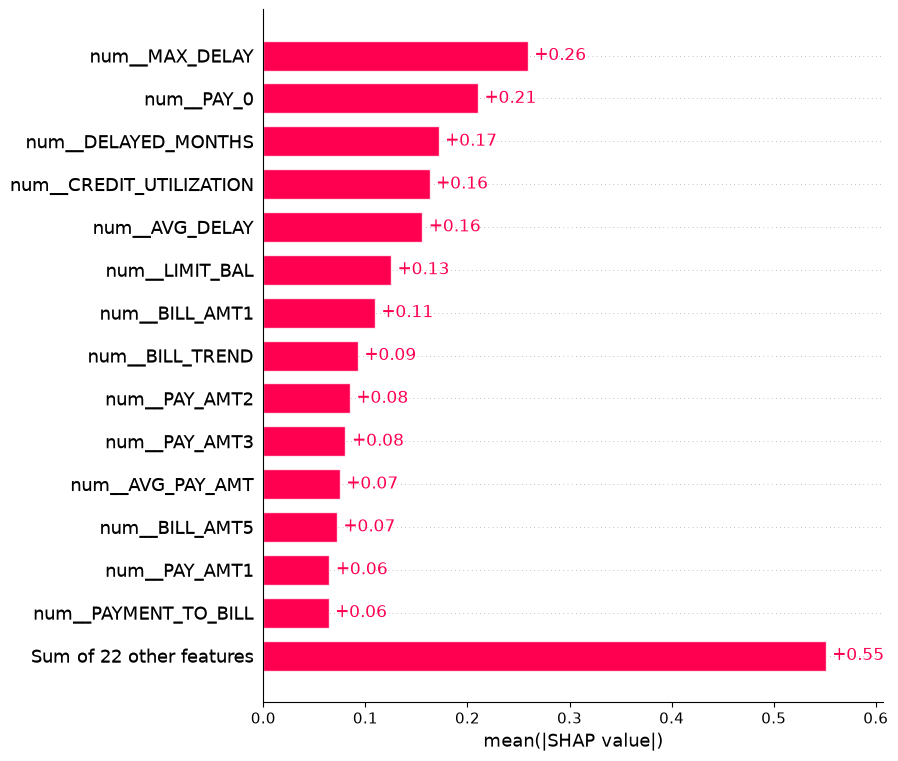

In [6]:
shap.plots.bar(
    shap_values,
    max_display=15
)

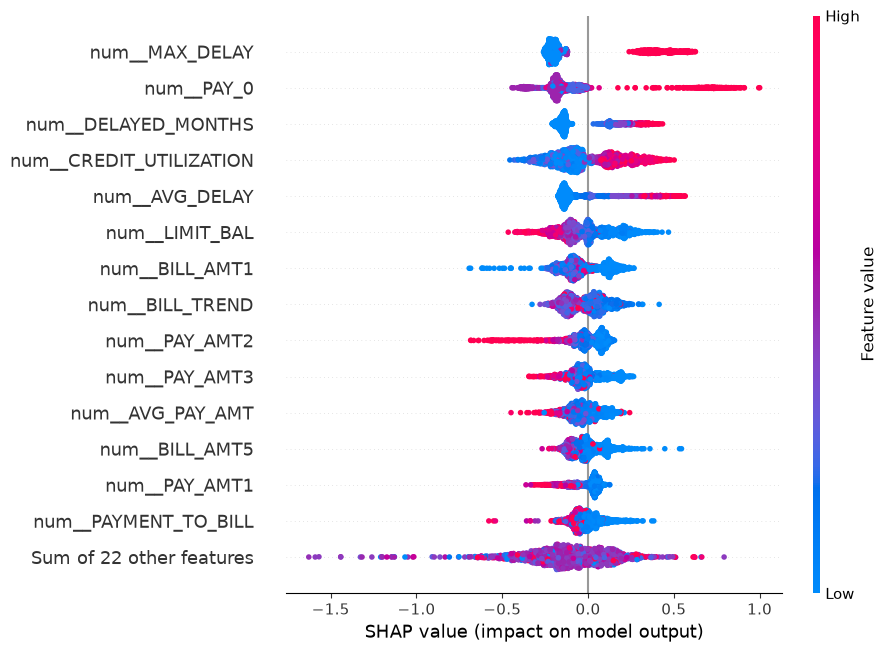

In [7]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [8]:
def clean_feature_name(name):
    name = name.replace("num__", "")
    name = name.replace("cat__", "")

    mapping = {
        "LIMIT_BAL": "Credit Limit",
        "PAY_0": "Recent Payment Status",
        "PAY_2": "Payment Status Month 2",
        "PAY_3": "Payment Status Month 3",
        "PAY_4": "Payment Status Month 4",
        "PAY_5": "Payment Status Month 5",
        "PAY_6": "Payment Status Month 6",
        "DELAYED_MONTHS": "Number of Delayed Months",
        "MAX_DELAY": "Maximum Payment Delay",
        "AVG_DELAY": "Average Payment Delay",
        "HAS_DELAY": "Previous Payment Delay",
        "RECENT_DELAY": "Recent Payment Delay",
        "AVG_BILL_AMT": "Average Bill Amount",
        "AVG_PAY_AMT": "Average Payment Amount",
        "TOTAL_BILL_AMT": "Total Bill Amount",
        "TOTAL_PAY_AMT": "Total Payment Amount",
        "CREDIT_UTILIZATION": "Credit Utilization",
        "PAYMENT_TO_BILL": "Payment-to-Bill Ratio",
        "BILL_TREND": "Bill Balance Trend",
        "PAYMENT_TREND": "Payment Trend",
        "EDUCATION_1": "Education: Graduate School",
        "EDUCATION_2": "Education: University",
        "EDUCATION_3": "Education: High School",
        "EDUCATION_4": "Education: Other"
    }

    return mapping.get(name, name)

In [9]:
clean_feature_names = [
    clean_feature_name(col)
    for col in X_shap_transformed.columns
]

clean_feature_names[:15]

['Credit Limit',
 'Recent Payment Status',
 'Payment Status Month 2',
 'Payment Status Month 3',
 'Payment Status Month 4',
 'Payment Status Month 5',
 'Payment Status Month 6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2']

In [10]:
RISK_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_risk_scores.csv"
)

risk_scores = pd.read_csv(RISK_PATH)

risk_scores.head()

,Customer_ID,Actual_Default,Probability_of_Default,Risk_Score,Risk_Band
0,25872,0,0.055322,94,Low
1,26119,0,0.054845,95,Low
2,15425,1,0.627280,37,High
3,23109,0,0.232609,77,Medium
4,1638,0,0.687629,31,High


In [11]:
high_risk_customer = (
    risk_scores
    .sort_values(
        "Probability_of_Default",
        ascending=False
    )
    .iloc[0]
)

high_risk_customer

Customer_ID                  17863
Actual_Default                   1
Probability_of_Default    0.728523
Risk_Score                      27
Risk_Band                     High
Name: 2649, dtype: object

In [12]:
customer_id = int(
    high_risk_customer["Customer_ID"]
)

customer_row = df[
    df["ID"] == customer_id
].copy()

customer_X = customer_row.drop(
    columns=excluded_cols
)

customer_transformed = (
    preprocessor_fitted.transform(customer_X)
)

if sparse.issparse(customer_transformed):
    customer_transformed = (
        customer_transformed.toarray()
    )

customer_transformed = pd.DataFrame(
    customer_transformed,
    columns=feature_names
)

print("Customer ID:", customer_id)
print(
    "PD:",
    round(
        high_risk_customer[
            "Probability_of_Default"
        ] * 100,
        2
    ),
    "%"
)
print(
    "Risk Band:",
    high_risk_customer["Risk_Band"]
)

Customer ID: 17863
PD: 72.85 %
Risk Band: High


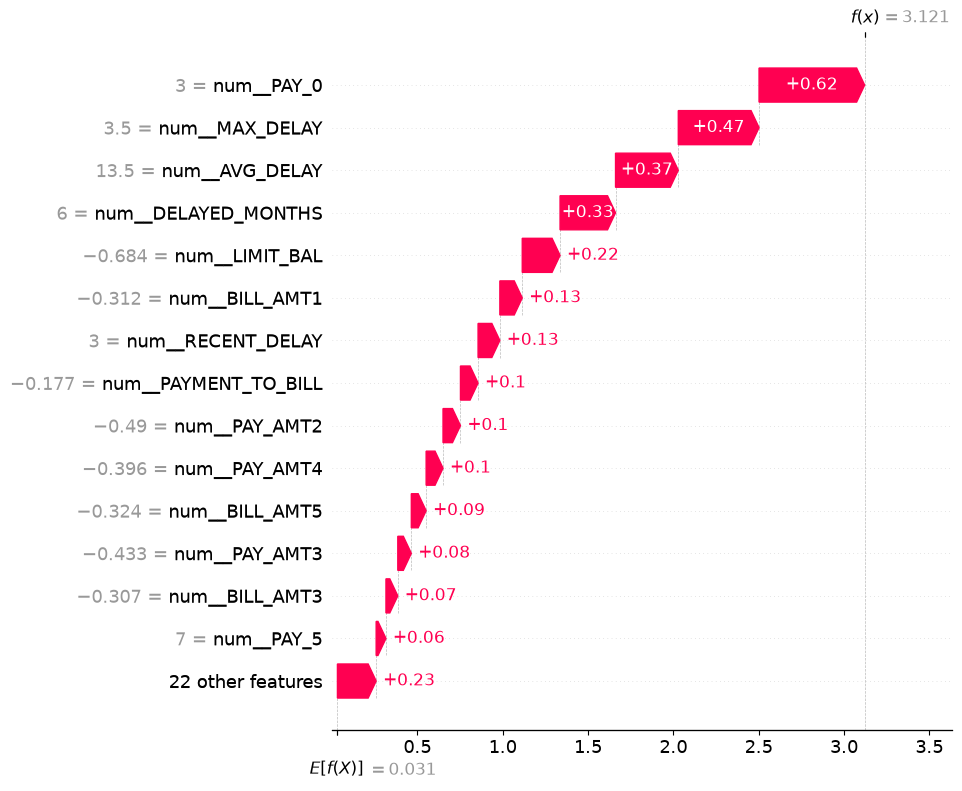

In [13]:
customer_shap = explainer(
    customer_transformed
)

shap.plots.waterfall(
    customer_shap[0],
    max_display=15
)

In [14]:
# =========================================
# PREPARE TEST CUSTOMERS FOR SHAP
# =========================================

test_ids = risk_scores["Customer_ID"].tolist()

test_feature_data = (
    df[df["ID"].isin(test_ids)]
    .set_index("ID")
    .loc[test_ids]
    .reset_index()
)

X_risk = test_feature_data.drop(
    columns=excluded_cols
)

X_risk_transformed = (
    preprocessor_fitted.transform(X_risk)
)

if sparse.issparse(X_risk_transformed):
    X_risk_transformed = (
        X_risk_transformed.toarray()
    )

X_risk_transformed = pd.DataFrame(
    X_risk_transformed,
    columns=feature_names
)

print(
    "Risk explanation dataset:",
    X_risk_transformed.shape
)

Risk explanation dataset: (4500, 36)


In [15]:
risk_shap_values = explainer(
    X_risk_transformed
)

print(
    "Risk SHAP shape:",
    risk_shap_values.values.shape
)

Risk SHAP shape: (4500, 36)


In [16]:
shap_array = risk_shap_values.values

feature_array = np.array(
    clean_feature_names
)

top_driver_1 = []
top_driver_2 = []
top_driver_3 = []

for row in shap_array:

    positive_idx = np.where(
        row > 0
    )[0]

    if len(positive_idx) == 0:
        top_driver_1.append(
            "No positive risk driver"
        )
        top_driver_2.append("")
        top_driver_3.append("")
        continue

    ranked_idx = positive_idx[
        np.argsort(
            row[positive_idx]
        )[::-1]
    ]

    drivers = [
        feature_array[i]
        for i in ranked_idx[:3]
    ]

    while len(drivers) < 3:
        drivers.append("")

    top_driver_1.append(drivers[0])
    top_driver_2.append(drivers[1])
    top_driver_3.append(drivers[2])

In [17]:
risk_scores["Main_Risk_Driver"] = (
    top_driver_1
)

risk_scores["Second_Risk_Driver"] = (
    top_driver_2
)

risk_scores["Third_Risk_Driver"] = (
    top_driver_3
)

risk_scores[
    [
        "Customer_ID",
        "Probability_of_Default",
        "Risk_Score",
        "Risk_Band",
        "Main_Risk_Driver",
        "Second_Risk_Driver",
        "Third_Risk_Driver"
    ]
].head(10)

,Customer_ID,Probability_of_Default,Risk_Score,Risk_Band,Main_Risk_Driver,Second_Risk_Driver,Third_Risk_Driver
0,25872,0.055322,94,Low,Number of Delayed Months,Bill Balance Trend,BILL_AMT1
1,26119,0.054845,95,Low,PAY_AMT1,Education: Other,Payment Status Month 4
2,15425,0.627280,37,High,Recent Payment Status,Maximum Payment Delay,Average Payment Delay
3,23109,0.232609,77,Medium,Maximum Payment Delay,Credit Utilization,Number of Delayed Months
4,1638,0.687629,31,High,Recent Payment Status,Maximum Payment Delay,Average Payment Delay
5,27350,0.293594,71,High,Maximum Payment Delay,PAY_AMT3,Payment Trend
6,19997,0.161102,84,Medium,Credit Utilization,Credit Limit,BILL_AMT4
7,12687,0.055322,94,Low,Credit Utilization,Bill Balance Trend,BILL_AMT3
8,4190,0.523178,48,High,Average Payment Delay,Maximum Payment Delay,Number of Delayed Months
9,27426,0.058670,94,Low,PAY_AMT4,PAY_AMT6,BILL_AMT3


In [18]:
FINAL_RISK_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_risk_scores_explained.csv"
)

risk_scores.to_csv(
    FINAL_RISK_PATH,
    index=False
)

print("Saved:")
print(FINAL_RISK_PATH)

print("\nShape:", risk_scores.shape)

Saved:
h:\Credit_Risk_Modeling\data\processed\customer_risk_scores_explained.csv

Shape: (4500, 8)


## Explainability Summary

SHAP was used to explain the XGBoost champion model.

### Global Explainability
- SHAP feature importance was used to identify the features that most strongly influence model predictions.
- Payment behavior, repayment persistence and credit utilization were analyzed as major credit-risk drivers.

### Local Explainability
- Individual customer predictions were explained using SHAP values.
- Positive SHAP values represent features that push the model prediction toward default.
- Negative SHAP values represent features that push the prediction toward non-default.

### Customer Risk Monitoring
For each customer in the test portfolio, the final output contains:

- Customer ID
- Calibrated Probability of Default
- Risk Score
- Risk Band
- Actual Default Status
- Main Risk Driver
- Second Risk Driver
- Third Risk Driver

The calibrated probability is used for Probability of Default and risk scoring, while SHAP explains the underlying XGBoost classification model.

Final explained risk data was saved as:

`customer_risk_scores_explained.csv`